In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Student_Satisfaction_Survey.csv", encoding='latin1')

df.head()

,SN,Total Feedback Given,Total Configured,Questions,Weightage 1,Weightage 2,Weightage 3,Weightage 4,Weightage 5,Average/ Percentage,Course Name,Basic Course
0,1,1,12,How much of the syllabus was covered in the cl...,0,0,1,0,0,3.00 / 60.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
1,2,1,12,How well did the teachers prepare for the clas...,0,0,0,0,1,5.00 / 100.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
2,3,1,12,How well were the teachers able to communicate?,0,0,0,0,1,5.00 / 100.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
3,4,1,12,The teachers approach to teaching can best be...,0,0,1,0,0,3.00 / 60.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
4,5,1,12,Fairness of the internal evaluation process by...,0,0,0,1,0,4.00 / 80.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 580 entries, 0 to 579
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   SN                    580 non-null    int64 
 1   Total Feedback Given  580 non-null    int64 
 2   Total Configured      580 non-null    int64 
 3   Questions             580 non-null    object
 4   Weightage 1           580 non-null    int64 
 5   Weightage 2           580 non-null    int64 
 6   Weightage 3           580 non-null    int64 
 7   Weightage 4           580 non-null    int64 
 8   Weightage 5           580 non-null    int64 
 9   Average/ Percentage   580 non-null    object
 10  Course Name           580 non-null    object
 11  Basic Course          580 non-null    object
dtypes: int64(8), object(4)
memory usage: 54.5+ KB


In [5]:
df.columns = df.columns.str.strip()

df.columns

Index(['SN', 'Total Feedback Given', 'Total Configured', 'Questions',
       'Weightage 1', 'Weightage 2', 'Weightage 3', 'Weightage 4',
       'Weightage 5', 'Average/ Percentage', 'Course Name', 'Basic Course'],
      dtype='object')

In [6]:
ratings = df[['Weightage 1','Weightage 2','Weightage 3','Weightage 4','Weightage 5']].sum()

ratings

,0
Weightage 1,306
Weightage 2,689
Weightage 3,1472
Weightage 4,2948
Weightage 5,2885


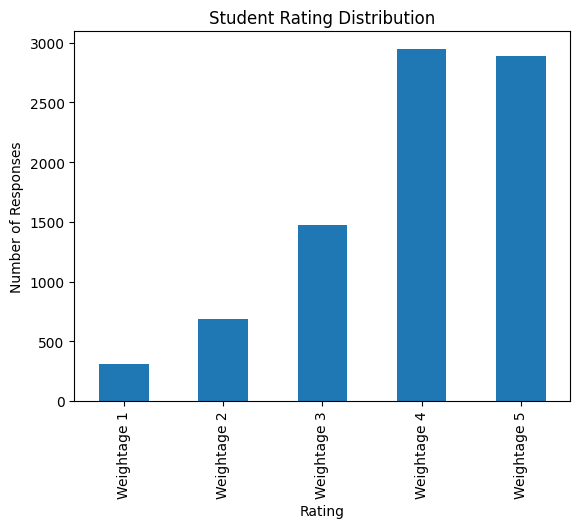

In [7]:
ratings.plot(kind='bar')

plt.title("Student Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Responses")

plt.show()

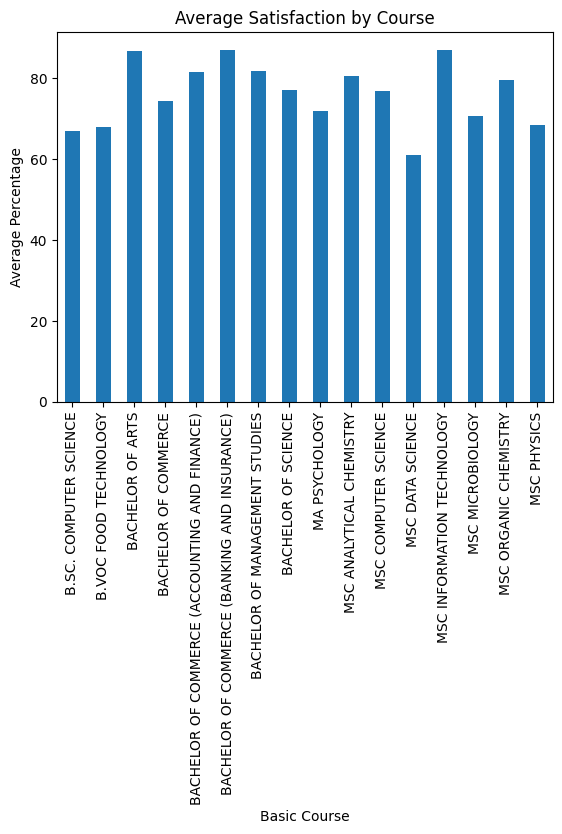

In [9]:
df['Percentage_Value'] = df['Average/ Percentage'].apply(lambda x: float(x.split('/')[-1].strip()))
course_feedback = df.groupby("Basic Course")["Percentage_Value"].mean()

course_feedback.plot(kind="bar")

plt.title("Average Satisfaction by Course")
plt.ylabel("Average Percentage")

plt.show()

In [10]:
top_questions = df.sort_values("Average/ Percentage", ascending=False)

top_questions[['Questions','Average/ Percentage']].head()

,Questions,Average/ Percentage
30,Your mentor does a necessary follow-up with an...,5.00 / 100.00
191,The teachers illustrate the concepts through e...,5.00 / 100.00
182,How well were the teachers able to communicate?,5.00 / 100.00
29,Teachers inform you about your expected compet...,5.00 / 100.00
31,The teachers illustrate the concepts through e...,5.00 / 100.00
